In [26]:
import numpy as np 
import matplotlib.pyplot as plt 
import pickle
import pyvisa
import time 
import os 
from datetime import datetime  
import nysg_tools as ny
import os
import pickle
import glob as glob
from scipy.optimize import curve_fit


In [76]:
file_list = sorted(glob.glob("11h_14m_42s/*.pkl"))

frequencies = []
r_values = []
phases = []
x_rms = []
y_rms = []
x_mean = []
x_err = []
y_err = []
for file in file_list:
    with open(file, "rb") as f:
        data = pickle.load(f)
        frequencies.append(data['frequency_Hz'])
        r_values.append(data['R_V_mean'])
        phases.append(data['Theta_deg_mean'])
        x_rms.append(data['X_V_mean'])
        y_rms.append(data['Y_V_mean'])

        x_err.append(data['X_V_std'])
        y_err.append(data['Y_V_std'])
        # etc...

In [77]:
np.min(x_rms)

-0.0113831

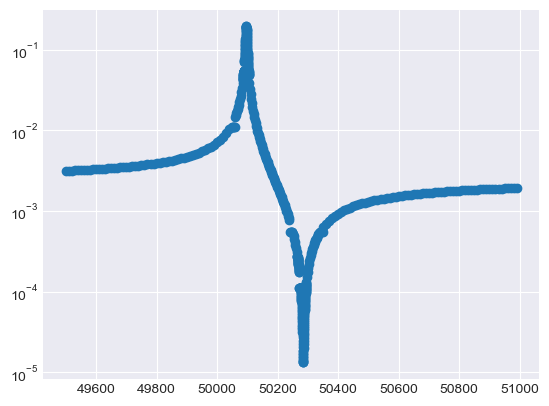

In [78]:
fig, ax = plt.subplots()

ax.scatter(frequencies,r_values)

ax.set_yscale("log")


In [79]:
def transfer_function(f, R, L, C, C2):
    R2 = 10000
    Cp = 300e-12  # 300 pF parasitic capacitance

    w = 2 * np.pi * f 

    # Piezoelectric impedance
    Zm = R + 1j * (w * L - 1 / (w * C))
    Z_pzt = 1 / (1 / Zm + 1j * w * C2)

    # Measurement impedance (R2 in parallel with Cp)
    Z_meas = 1 / (1 / R2 + 1j * w * Cp) 
    
    # Transfer function
    H = Z_meas / (Z_pzt + Z_meas) 

    return H

In [80]:

def fit_func(f_concat, R, L, C, C2):

    N = len(f_concat) // 2 
    f = f_concat[:N]

    H = transfer_function(f, R, L, C, C2)

    return np.concatenate([H.real, H.imag])

In [81]:
freq_fit = np.concatenate([np.array(frequencies), np.array(frequencies)])

initial_guess = [4000, 410, 2.3679e-14, 2.996e-12]

X_data = np.array(x_rms)
Y_data = np.array(y_rms)

data_to_fit = np.concatenate([np.array(X_data), np.array(Y_data)])


# Create the error vector to match our concatenated data (Real + Imaginary)
data_errors = np.concatenate([x_err, y_err])

# Update curve_fit to include the sigma parameter
popt, pcov = curve_fit(
    fit_func, 
    freq_fit, 
    data_to_fit, 
    p0=initial_guess, 
    # sigma=data_errors,  # This adds the weighting!
    # absolute_sigma=True, 
    maxfev=10000000
)

R_fit, L_fit, C_fit, C2_fit = popt
print(f"Fitted parameters: R = {R_fit:.4f} Ohms, L = {L_fit:.4f} H, C = {C_fit:.4e} F, C2 = {C2_fit:.4e} F")


Fitted parameters: R = 177166.1931 Ohms, L = -341.4088 H, C = -2.9590e-14 F, C2 = -1.1631e-12 F


In [ ]:
inst.close

In [82]:
# Get model predictions at the fitted frequencies
model_output = fit_func(freq_fit, *popt)

# Calculate Chi-Squared
residuals = data_to_fit - model_output
chisq = np.sum((residuals / data_errors)**2)

# Calculate Reduced Chi-Squared
dof = len(data_to_fit) - len(popt) # Degrees of freedom
chisq_red = chisq / dof

print(f"Chi-Squared: {chisq:.4f}")
print(f"Reduced Chi-Squared (χ²/dof): {chisq_red:.4f}")

Chi-Squared: inf
Reduced Chi-Squared (χ²/dof): inf


C:\Users\publico\AppData\Local\Temp\ipykernel_12756\1875866591.py:6: RuntimeWarning: divide by zero encountered in divide
  chisq = np.sum((residuals / data_errors)**2)


C:\Users\publico\AppData\Local\Temp\ipykernel_12756\709805432.py:30: UserWarning: Glyph 129480 (\N{BUTTER}) missing from current font.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129480 (\N{BUTTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


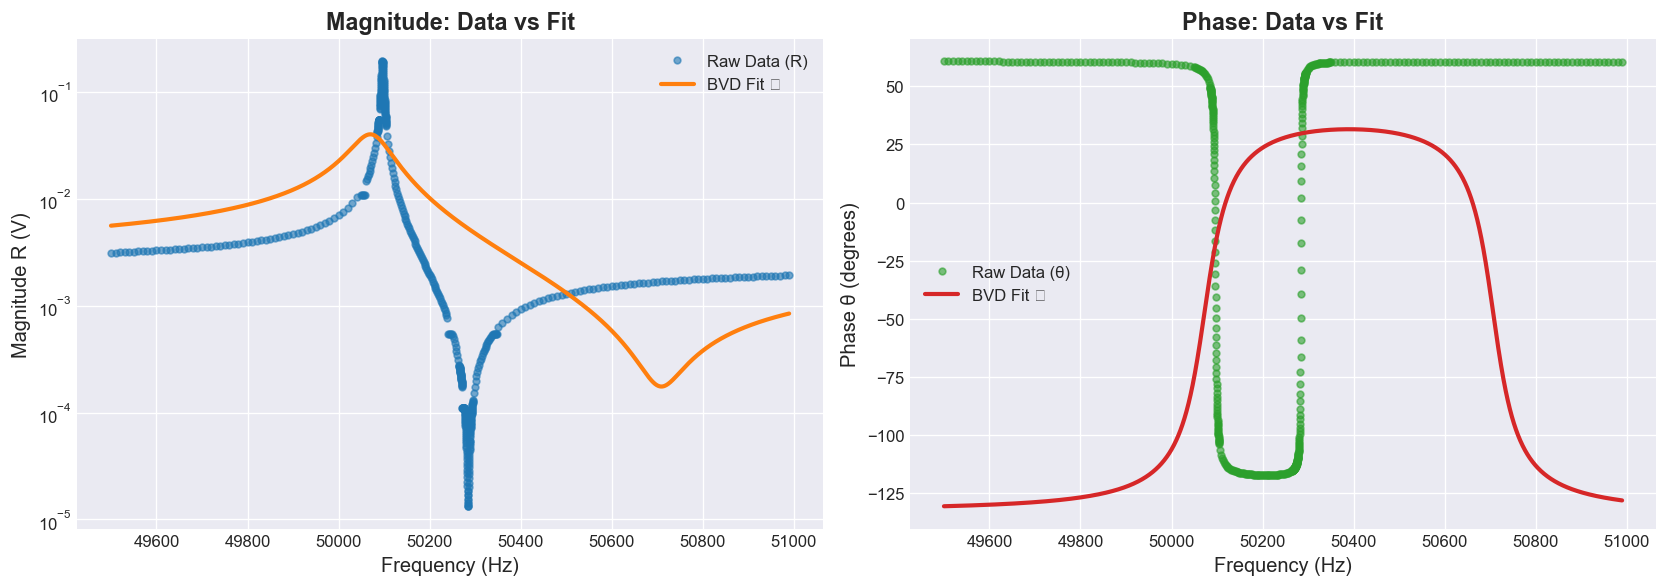

In [83]:
# Generate a high-res frequency array for a butter-smooth fit line 🧈
f_smooth = np.linspace(min(frequencies), max(frequencies), 2000)
H_fit = transfer_function(f_smooth, R_fit, L_fit, C_fit, C2_fit)

# Calculate R (Magnitude) and Theta (Phase in degrees) for the model
R_model = np.abs(H_fit)
Theta_model = np.angle(H_fit, deg=True)

# Make it pretty
plt.style.use('seaborn-v0_8-darkgrid') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# --- Magnitude R ---
ax1.plot(frequencies, r_values, 'o', color='#1f77b4', markersize=4, alpha=0.6, label='Raw Data (R)')
ax1.plot(f_smooth, R_model, '-', color='#ff7f0e', linewidth=2.5, label='BVD Fit 🧈')
ax1.set_yscale('log')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Magnitude R (V)', fontsize=12)
ax1.set_title('Magnitude: Data vs Fit', fontsize=14, fontweight='bold')
ax1.legend(loc='best')

# --- Phase Theta ---
ax2.plot(frequencies, phases, 'o', color='#2ca02c', markersize=4, alpha=0.6, label='Raw Data (θ)')
ax2.plot(f_smooth, Theta_model, '-', color='#d62728', linewidth=2.5, label='BVD Fit 🧈')
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Phase θ (degrees)', fontsize=12)
ax2.set_title('Phase: Data vs Fit', fontsize=14, fontweight='bold')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

RESIDUALS & CHI2 VIBE CHECK
Sum of Squared Residuals: 9.8817e-03
Reduced Chi-Squared (χ²/dof): 6.6409e-06
Mean Abs Error: 1.3059e-03 V


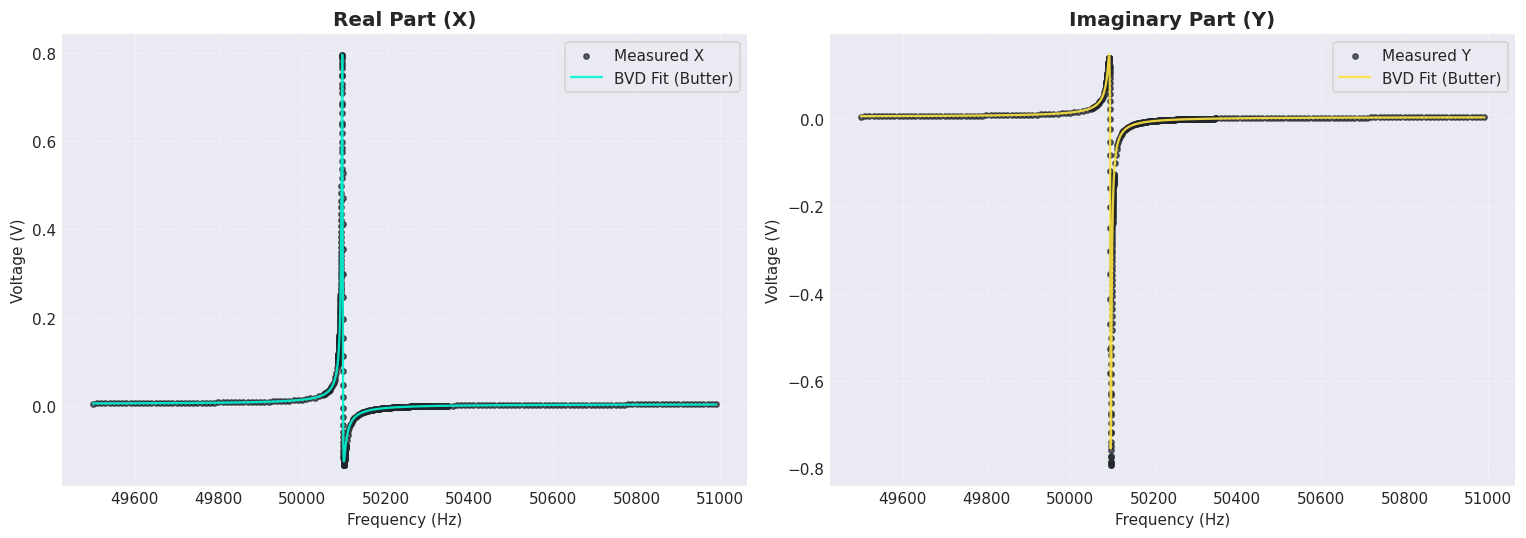

In [ ]:
# 1. Generate smooth fit
f_smooth = np.linspace(min(frequencies), max(frequencies), 2000)
H_smooth = transfer_function(f_smooth, R_fit, L_fit, C_fit, C2_fit)
X_smooth, Y_smooth = np.real(H_smooth), np.imag(H_smooth)

# 2. Stats Recap
y_model_at_data = fit_func(freq_fit, *popt)
residuals = data_to_fit - y_model_at_data
ssr = np.sum(residuals**2)
dof = len(data_to_fit) - len(popt)
reduced_chi2 = ssr / dof

print(f"{'='*30}")
print(f"RESIDUALS & CHI2 VIBE CHECK")
print(f"{'='*30}")
print(f"Sum of Squared Residuals: {ssr:.4e}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi2:.4e}")
print(f"Mean Abs Error: {np.mean(np.abs(residuals)):.4e} V")

# 3. Chiller Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Real Part (X)
# Data is zorder 3 (top), Fit is zorder 2 (behind)
ax1.scatter(frequencies, x_rms, color='#212529', s=12, alpha=0.7, label='Measured X', zorder=1)
ax1.plot(f_smooth, X_smooth, color='#00f5d4', linewidth=1.5, alpha=0.9, label='BVD Fit (Butter)', zorder=2)
ax1.set_title("Real Part (X)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Voltage (V)")
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(frameon=True)

# Imaginary Part (Y)
ax2.scatter(frequencies, y_rms, color='#212529', s=12, alpha=0.7, label='Measured Y', zorder=1)
ax2.plot(f_smooth, Y_smooth, color='#fee440', linewidth=1.5, alpha=0.9, label='BVD Fit (Butter)', zorder=2)
ax2.set_title("Imaginary Part (Y)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Voltage (V)")
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

RESIDUAL STATS (VOLTS)
X - Mean: -4.37e-04 | Std Dev: 2.62e-03
Y - Mean: -6.36e-04 | Std Dev: 2.40e-03



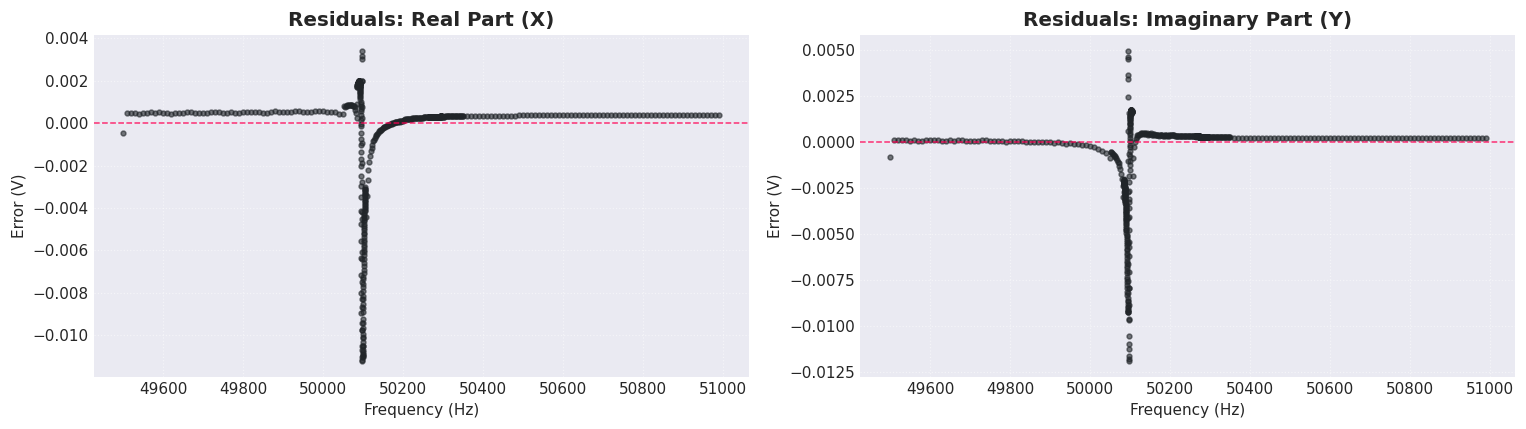

In [ ]:

# 1. Calculate the residuals for each component
# We need the model values exactly at the measured frequencies
H_at_data = transfer_function(np.array(frequencies), R_fit, L_fit, C_fit, C2_fit)
res_x = x_rms - np.real(H_at_data)
res_y = y_rms - np.imag(H_at_data)

# 2. Print the numerical vibe check
print(f"{'='*30}")
print(f"RESIDUAL STATS (VOLTS)")
print(f"{'='*30}")
print(f"X - Mean: {np.mean(res_x):.2e} | Std Dev: {np.std(res_x):.2e}")
print(f"Y - Mean: {np.mean(res_y):.2e} | Std Dev: {np.std(res_y):.2e}")
print(f"{'='*30}\n")

# 3. Plotting the residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), dpi=110)

# Residuals X
ax1.scatter(frequencies, res_x, color='#212529', s=10, alpha=0.6, label='X Residuals')
ax1.axhline(0, color='#ff0054', linestyle='--', linewidth=1, alpha=0.8) # Zero line
ax1.set_title("Residuals: Real Part (X)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Error (V)")
ax1.grid(True, linestyle=':', alpha=0.5)

# Residuals Y
ax2.scatter(frequencies, res_y, color='#212529', s=10, alpha=0.6, label='Y Residuals')
ax2.axhline(0, color='#ff0054', linestyle='--', linewidth=1, alpha=0.8) # Zero line
ax2.set_title("Residuals: Imaginary Part (Y)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Error (V)")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()